In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, itertools, sys
from pathlib import Path
from tqdm import tqdm

sys.path.append('../..')
from Dataset.index import Normalization

# COMPARANDO dataset_wu E dataset_zu

- O `dataset_zu` é o `200-20.zip` que os autores da ResACEUnet publicaram no Zenodo; o `dataset_wu` é o FaultSeg3D (Wu et al. 2019) em `.dat`.
- A pergunta é se são o mesmo dado: a comparação usa os volumes crus do `original/` dos dois, antes de qualquer `Format`.
- Os números dos arquivos não batem (o zu renumerou), então primeiro se acha o par de cada volume pelas estatísticas e depois se confere voxel a voxel.

In [2]:
WU = '../dataset_wu/original'
ZU = 'original'

def getWu(name, folder='images'):
    return np.fromfile(f'{WU}/{folder}/{name}', dtype=np.float32).reshape((128, 128, 128))

def getZu(name, folder='images'):
    return np.load(f'{ZU}/{folder}/{name}').astype(np.float32)

wuNames = sorted(os.listdir(f'{WU}/images'), key=lambda name: int(Path(name).stem))
zuNames = sorted(os.listdir(f'{ZU}/images'), key=lambda name: int(Path(name).stem))

print(len(wuNames), 'volumes no wu |', len(zuNames), 'no zu')
pd.DataFrame({'wu': wuNames[:5], 'zu': zuNames[:5]})

220 volumes no wu | 220 no zu


,wu,zu
0,0.dat,0.npy
1,1.dat,1.npy
2,2.dat,2.npy
3,3.dat,3.npy
4,4.dat,4.npy


# ESTATÍSTICAS POR VOLUME

- Média, desvio e fração de falha de cada volume, nos dois conjuntos.
- Se as listas ordenadas forem iguais, os dois têm os mesmos volumes, só em outra ordem.

In [3]:
# UMA LINHA POR VOLUME: MÉDIA, DESVIO, FRAÇÃO DE FALHA E A ASSINATURA (VALORES EM ORDEM CRESCENTE, QUE NÃO MUDAM COM GIRO OU ESPELHO)
def getStats(names, getter):
    rows = []
    for name in tqdm(names):
        img, mask = getter(name), getter(name, 'masks')
        rows.append({'name': name, 'mean': float(img.mean()), 'std': float(img.std()), 'fault': float(mask.mean()), 'signature': np.sort(img, axis=None)[::4096]})
    return pd.DataFrame(rows)


wuStats, zuStats = getStats(wuNames, getWu), getStats(zuNames, getZu)
pd.DataFrame({column: [float(np.abs(np.sort(wuStats[column]) - np.sort(zuStats[column])).max())] for column in ('mean', 'std', 'fault')}, index=['max |dif| entre as listas ordenadas'])

100%|██████████| 220/220 [00:06<00:00, 34.92it/s]


,mean,std,fault
max |dif| entre as listas ordenadas,0.0,0.0,0.0


# PAREAMENTO

- Cada volume do zu ganha o par do wu com a assinatura mais próxima: os valores do volume em ordem crescente, que não mudam com giro nem espelho.
- O desvio sozinho não serve: os volumes do wu já vêm padronizados, quase todos com desvio ~1, e vários colidem.
- O par tem de ser único: 220 pares para 220 volumes.

In [4]:
signatures = np.stack(wuStats.signature)
pairs      = pd.DataFrame({'zu': zuStats.name, 'wu': [wuStats.name[int(np.argmin(np.abs(signatures - signature).sum(axis=1)))] for signature in zuStats.signature]})

print('pares únicos:', pairs.wu.nunique(), 'de', len(pairs))
pairs.head(10)

pares únicos: 220 de 220


,zu,wu
0,0.npy,69.dat
1,1.npy,143.dat
2,2.npy,29.dat
3,3.npy,58.dat
4,4.npy,122.dat
5,5.npy,193.dat
6,6.npy,119.dat
7,7.npy,96.dat
8,8.npy,65.dat
9,9.npy,13.dat


# VOXEL A VOXEL

- Cada par é comparado nas 48 orientações possíveis (6 transposições × 8 espelhamentos), imagem e máscara.
- Igualdade exata, sem tolerância; a primeira orientação que bate é a que fica na tabela.

In [5]:
ORIENTATIONS = [(perm, flips) for perm in itertools.permutations(range(3)) for flips in itertools.product((False, True), repeat=3)]

# TRANSPÕE E ESPELHA UM VOLUME NUMA DAS 48 ORIENTAÇÕES
def orient(volume, perm, flips):
    volume = np.transpose(volume, perm)
    axes   = tuple(axis for axis, flip in enumerate(flips) if flip)
    return np.flip(volume, axes) if axes else volume

# ORIENTAÇÃO EM QUE O VOLUME DO WU É IGUAL AO DO ZU, E SE A MÁSCARA TAMBÉM BATE NELA
def match(zuName, wuName):
    zu, wu = getZu(zuName), getWu(wuName)
    for perm, flips in ORIENTATIONS:
        if np.array_equal(orient(wu, perm, flips), zu):
            return f'{perm} espelho {flips}' if any(flips) else str(perm), np.array_equal(orient(getWu(wuName, 'masks'), perm, flips), getZu(zuName, 'masks'))
    return 'nenhuma', False


found = [match(zu, wu) for zu, wu in tqdm(zip(pairs.zu, pairs.wu), total=len(pairs))]
pairs['orientation'], pairs['mask_equal'] = [item[0] for item in found], [item[1] for item in found]

print('imagens iguais:', (pairs.orientation != 'nenhuma').sum(), '/', len(pairs), '| máscaras iguais:', pairs.mask_equal.sum(), '/', len(pairs))
pairs.orientation.value_counts()

100%|██████████| 220/220 [00:02<00:00, 87.31it/s]

imagens iguais: 220 / 220 | máscaras iguais: 220 / 220


orientation
(0, 1, 2)    220
Name: count, dtype: int64

# DIVISÃO DOS AUTORES

- O zip separa treino (0–199) e validação (200–219); a tabela mostra de que bloco do wu vem cada parte.
- O FaultSeg3D também separa os 200 de treino dos 20 de validação, que no `dataset_wu` são os números 200–219.

In [6]:
pairs['zu_split'] = ['treino' if int(Path(name).stem) < 200 else 'validação' for name in pairs.zu]
pairs['wu_block'] = ['0–199' if int(Path(name).stem) < 200 else '200–219' for name in pairs.wu]

print('volumes que mantiveram o número:', sum(Path(zu).stem == Path(wu).stem for zu, wu in zip(pairs.zu, pairs.wu)))
pd.crosstab(pairs.zu_split, pairs.wu_block)

volumes que mantiveram o número: 2


wu_block,0–199,200–219
zu_split,,
treino,200,0
validação,0,20


# DEPOIS DO FORMAT

- Os `images/` dos dois saem do mesmo `Format`, só com a leitura diferente; o `scaling` de cada um está na coluna do `DataBase.csv`.
- Para comparar mesmo com normalizações diferentes, o min-max é refeito nos dois tiles: ele anula qualquer escala e deslocamento, então tiles iguais na origem têm de bater.

In [7]:
def minmax(img):
    return (img - img.min()) / (img.max() - img.min())


scaling   = {name: Normalization.read(f'{path}/DataBase.csv') for name, path in (('wu', '../dataset_wu'), ('zu', '.'))}
diffs     = [float(np.abs(minmax(np.load(f'images/{zu}')) - minmax(np.load(f'../dataset_wu/images/{Path(wu).stem}.npy'))).max()) for zu, wu in tqdm(zip(pairs.zu, pairs.wu), total=len(pairs))]

print('scaling no DataBase.csv:', scaling)
print(f'max |dif| entre os tiles formatados do par, no mesmo min-max: {max(diffs):.2e}')

100%|██████████| 220/220 [00:02<00:00, 89.24it/s]

normalize no DataBase.csv: {'wu': np.True_, 'zu': np.False_}
max |dif| entre os tiles formatados do par, no mesmo min-max: 2.38e-07


# FIGURA

- O mesmo corte do primeiro par nos dois conjuntos, cru, com a máscara por cima (o tempo é o último eixo nos dois).

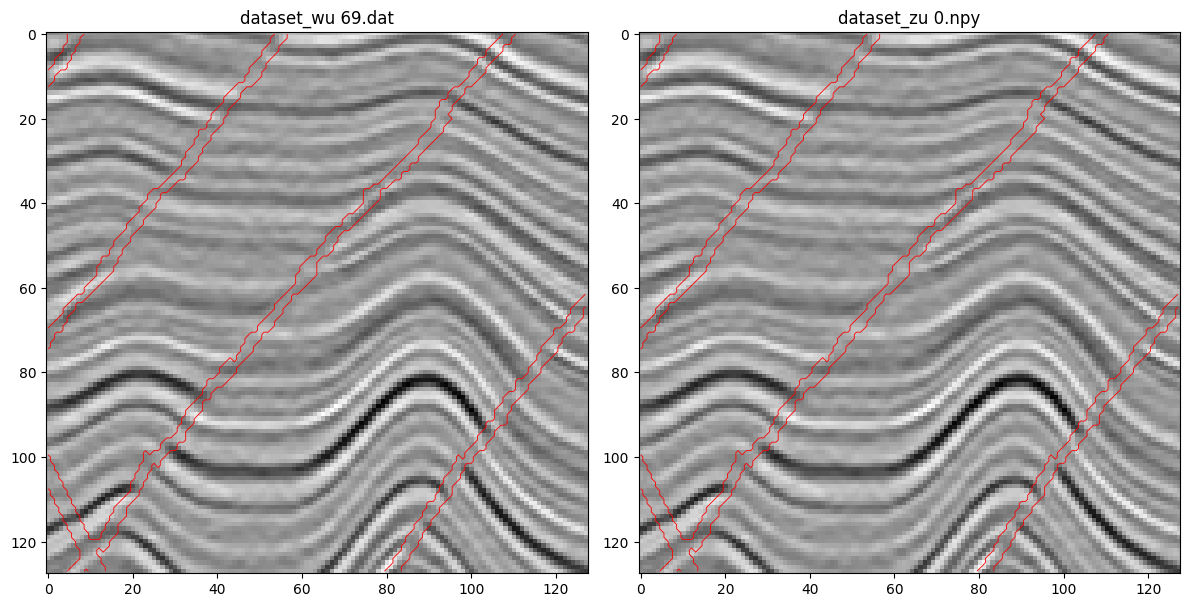

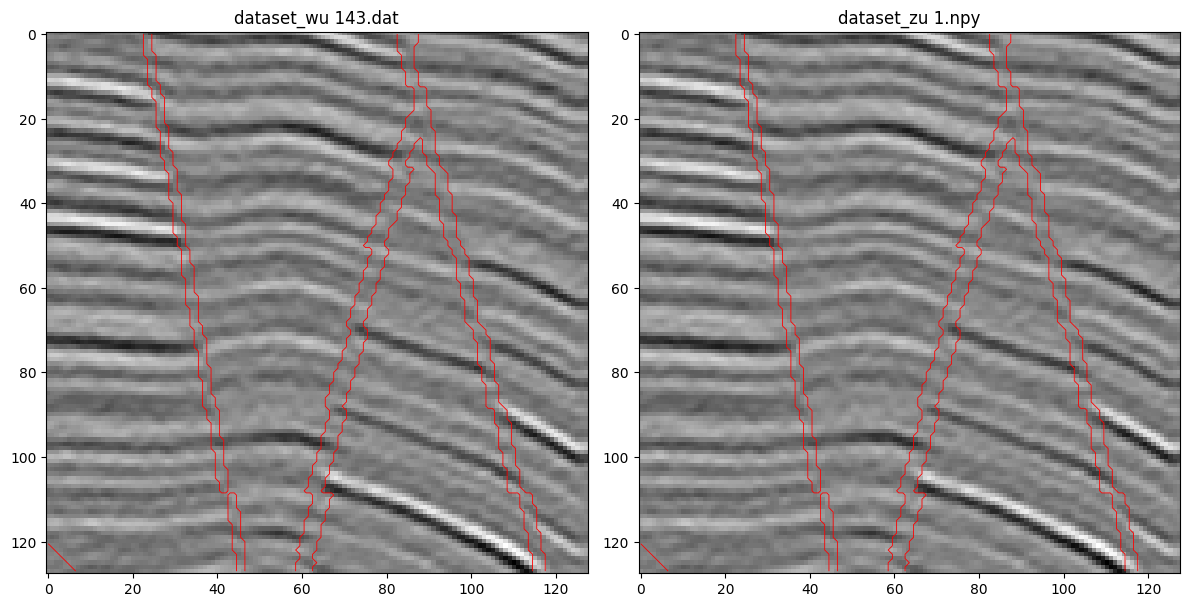

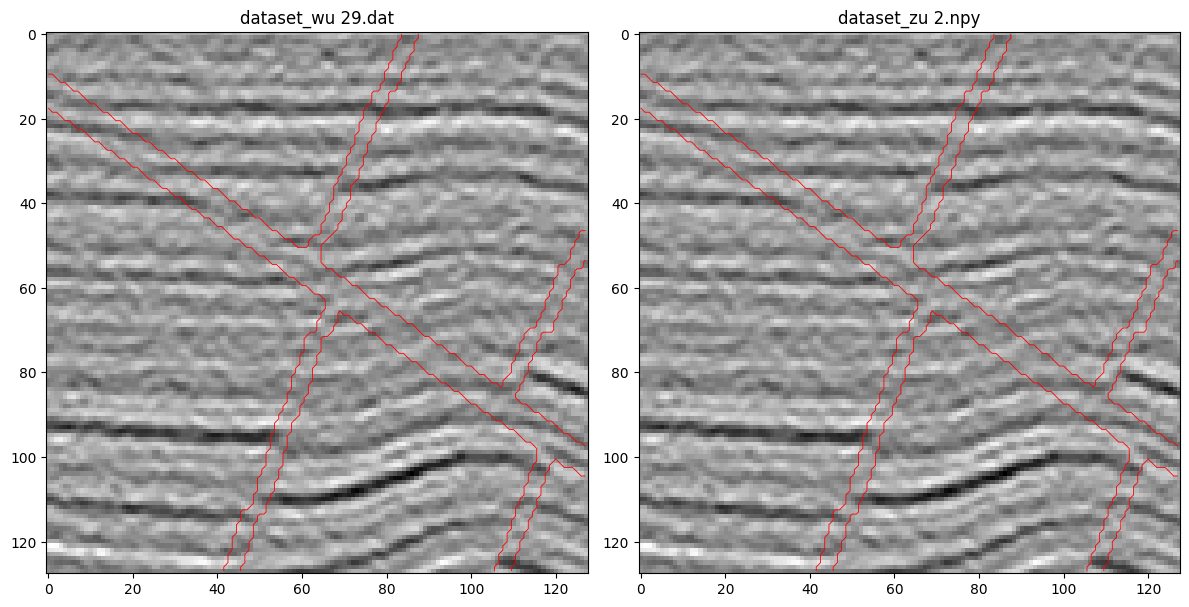

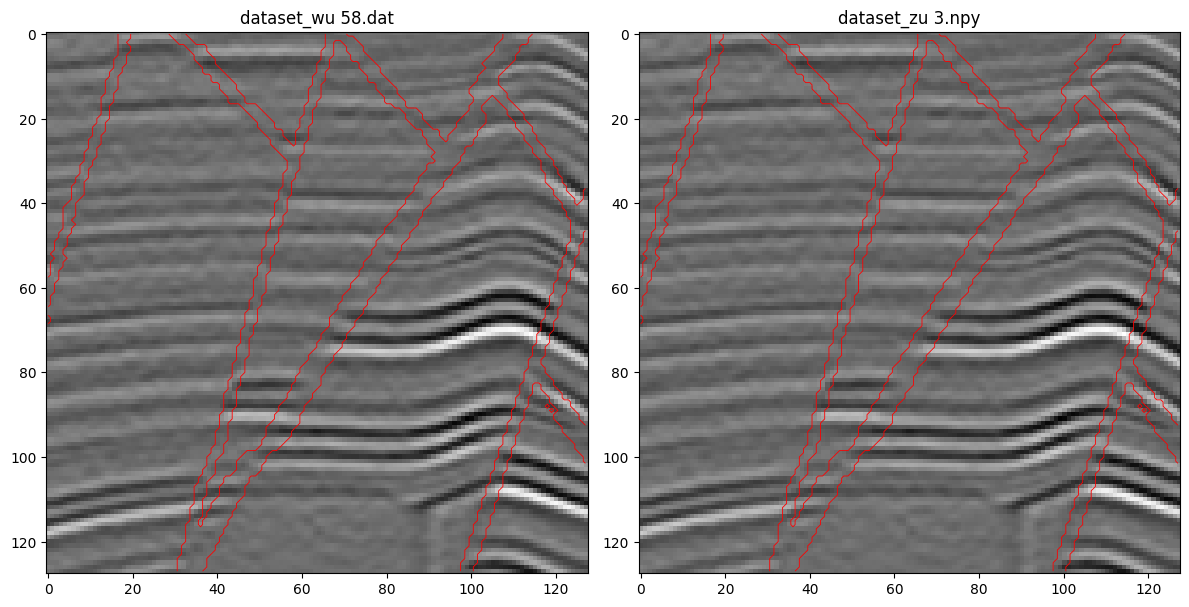

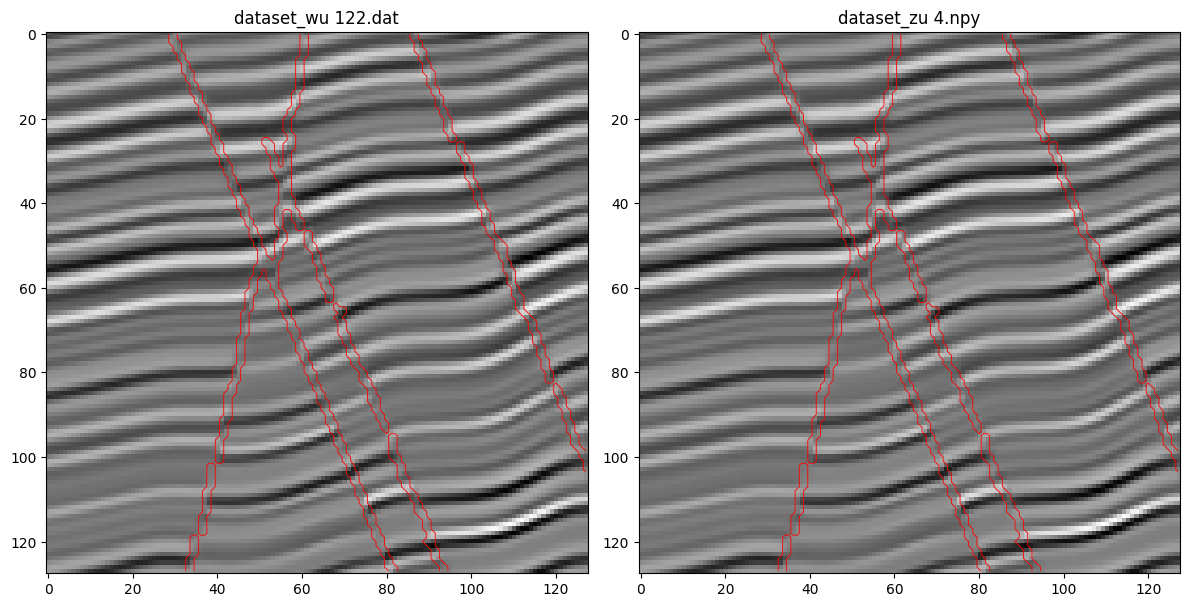

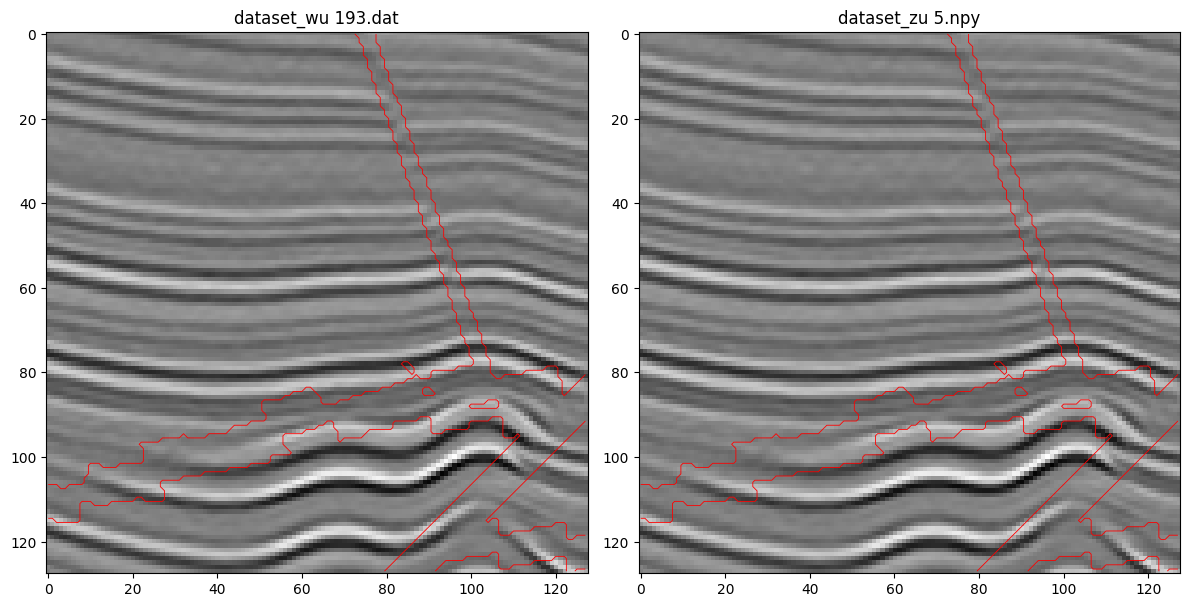

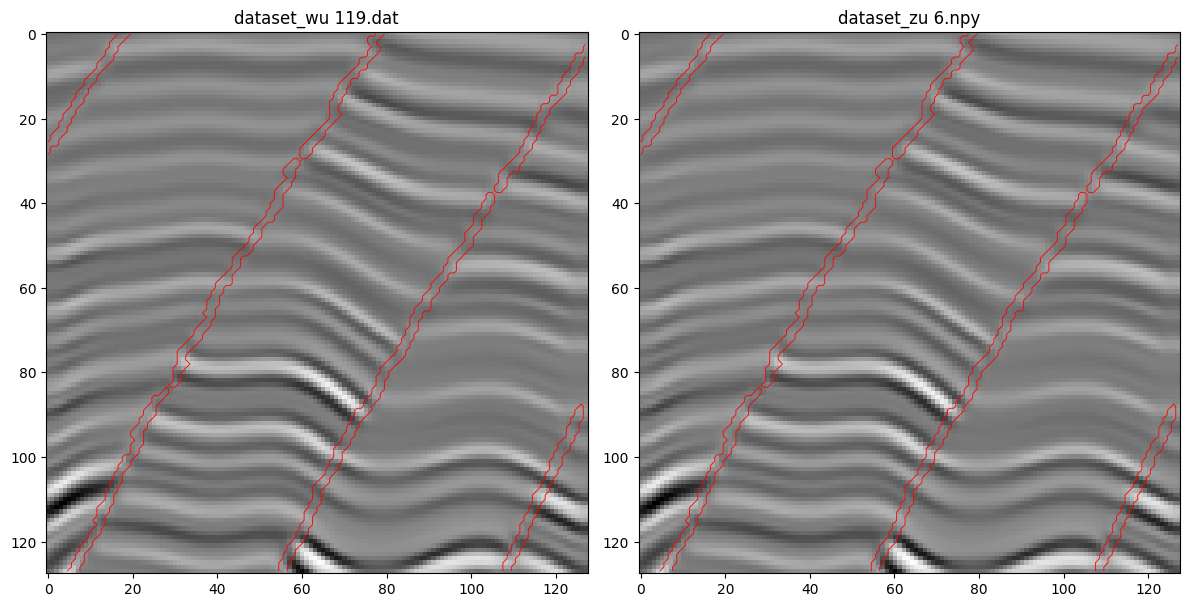

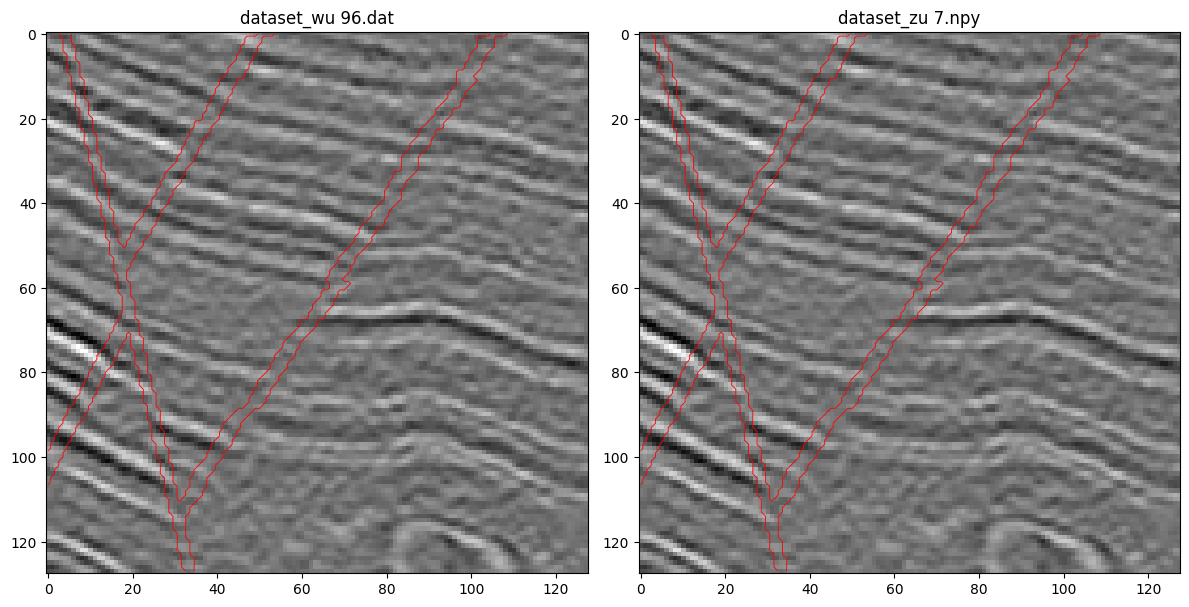

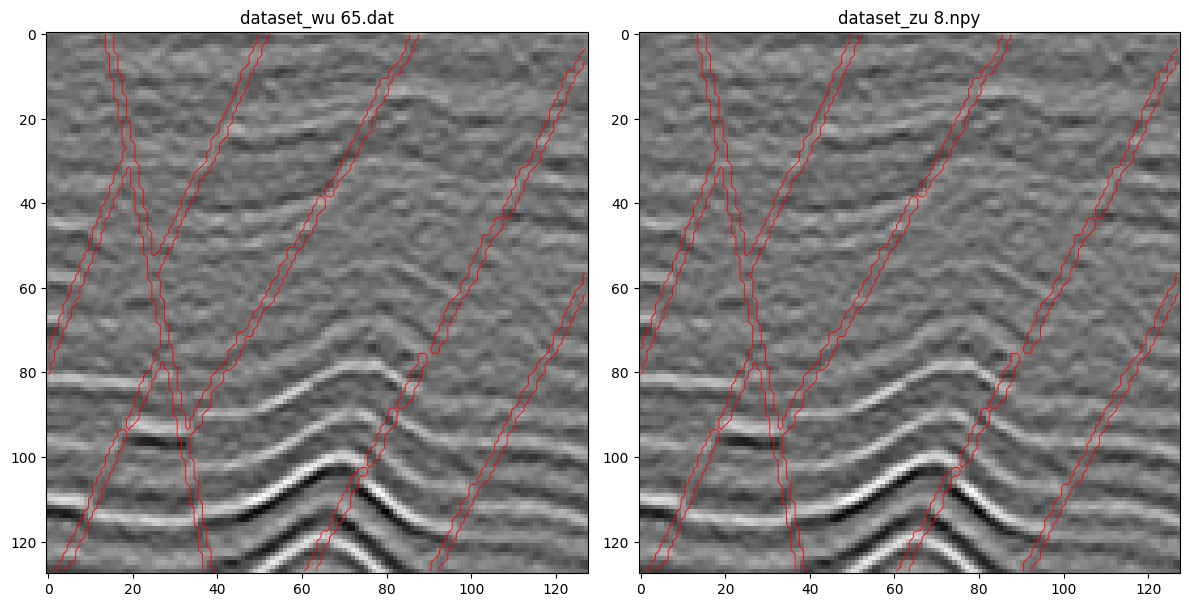

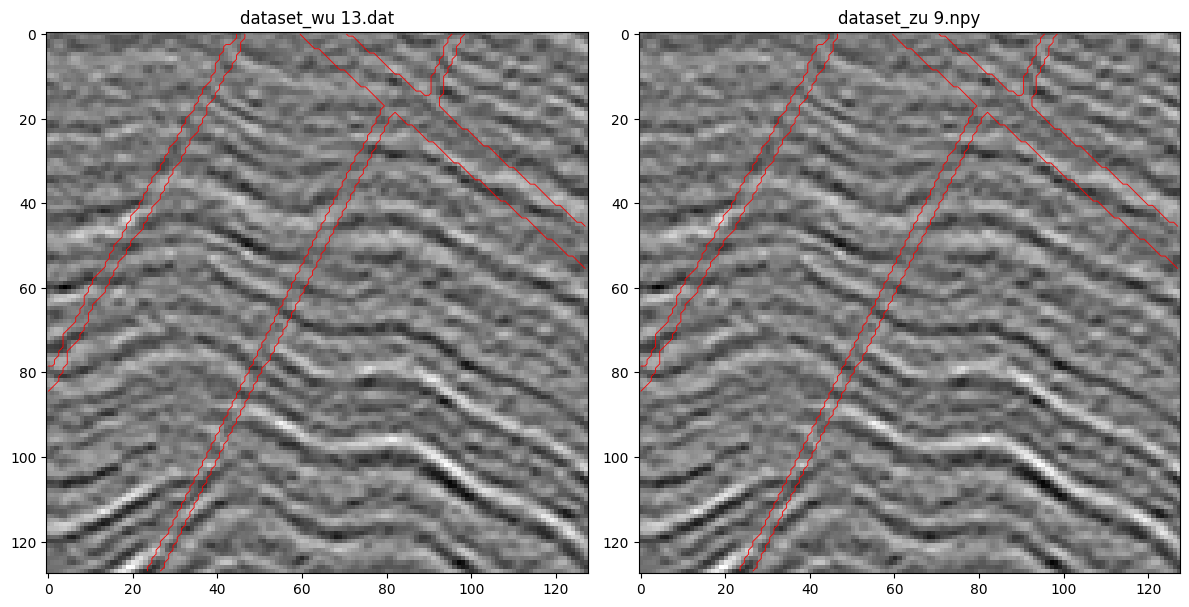

In [10]:
for i in range(10):
    zuName, wuName = pairs.zu[i], pairs.wu[i]
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, (title, img, mask) in zip(axes, [(f'dataset_wu {wuName}', getWu(wuName), getWu(wuName, 'masks')), (f'dataset_zu {zuName}', getZu(zuName), getZu(zuName, 'masks'))]):
        ax.imshow(img[64].T, cmap='gray')
        ax.contour(mask[64].T, [0.5], colors='red', linewidths=0.6)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

# CONCLUSÃO

In [9]:
same = pairs.wu.nunique() == len(pairs) and (pairs.orientation == '(0, 1, 2)').all() and pairs.mask_equal.all()

print('dataset_zu e dataset_wu são o mesmo dado, bit a bit, só renumerado' if same else 'há volumes diferentes: ver as linhas abaixo')
pairs[(pairs.orientation != '(0, 1, 2)') | ~pairs.mask_equal]

dataset_zu e dataset_wu são o mesmo dado, bit a bit, só renumerado


,zu,wu,orientation,mask_equal,zu_split,wu_block
